In [105]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [106]:
with open("processed_battery_features_v2.pkl", "rb") as f:
    feature_df = pickle.load(f)

In [107]:
model_df = feature_df.dropna().copy()

feature_columns = [
    'I_mean',
    'I_std',
    'charge_duration',
    # 'discharge_duration',
    'V_mean',
    'V_std',
    'DTW_I',
    'DTW_V',

    # neue Spannungskurven-Features
    'V_range',
    'V_slope_mean',
    'V_curvature',
    'V_n_peaks'
]

# feature_columns = [
#     "DTW_V",
#     "V_mean",
#     "V_std",
#     "V_curvature",
#     "V_n_peaks"
# ]


# feature_columns = [
#     # Core degradation signal
#     "DTW_V",
#     "V_curvature",
#     "V_std",
#     "V_mean",

#     # Capacity / time proxy (sehr wichtig in deinem Datensatz)
#     "discharge_duration",
#     "charge_duration"
# ]

target_column = "SOH"

features = model_df[feature_columns]
target = model_df[target_column]

In [108]:
# Aufteilen in Trainings- und Testdaten
features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [109]:
# Einfaches Random Forest Regressor Modell

model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(features_train, target_train)

pred_test = model_rf.predict(features_test)

In [110]:


print("MAE:", mean_absolute_error(target_test, pred_test))
print("R2:", r2_score(target_test, pred_test))

MAE: 0.005727329776777597
R2: 0.9841119243767432


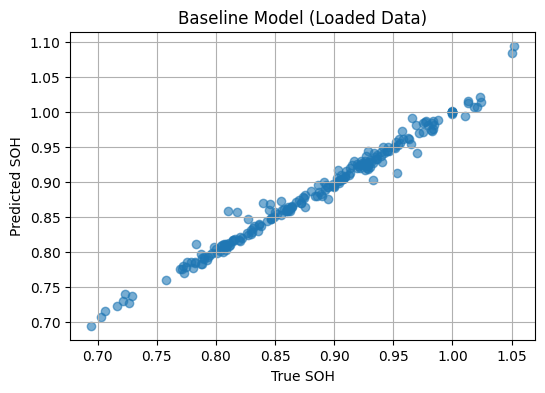

In [111]:
# Visualisierung der Vorhersagen
plt.figure(figsize=(6,4))

plt.scatter(target_test, pred_test, alpha=0.6)

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Baseline Model (Loaded Data)")
plt.grid(True)

plt.show()

In [112]:
importance_df = pd.DataFrame({
    "feature": features_train.columns,
    "importance": model_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df)

            feature  importance
6             DTW_V    0.446992
1             I_std    0.229018
2   charge_duration    0.159538
9       V_curvature    0.049231
3            V_mean    0.033986
4             V_std    0.022283
0            I_mean    0.017318
5             DTW_I    0.017165
10        V_n_peaks    0.012709
8      V_slope_mean    0.007691
7           V_range    0.004069


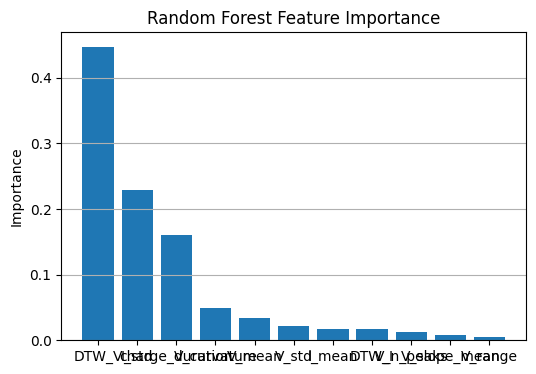

In [113]:
plt.figure(figsize=(6, 4))

plt.bar(
    importance_df["feature"],
    importance_df["importance"]
)

plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.grid(axis="y")

plt.show()

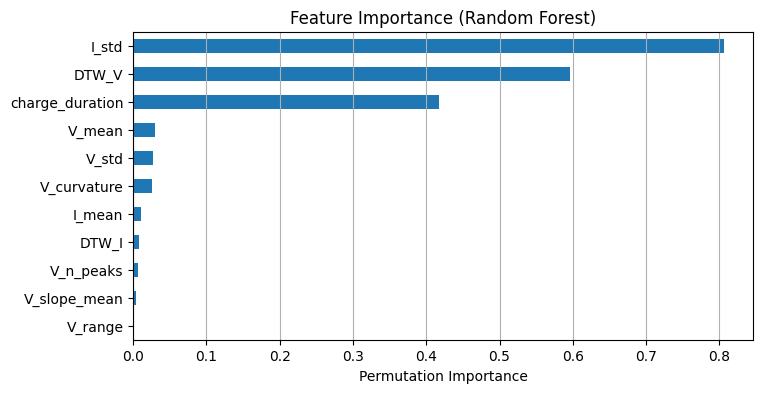

In [114]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model_rf,                 # dein Random Forest
    features_test,
    target_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    result.importances_mean,
    index=features_test.columns
)

perm_importance.sort_values().plot(
    kind="barh",
    figsize=(8, 4)
)

plt.xlabel("Permutation Importance")
plt.title("Feature Importance (Random Forest)")
plt.grid(axis="x")
plt.show()

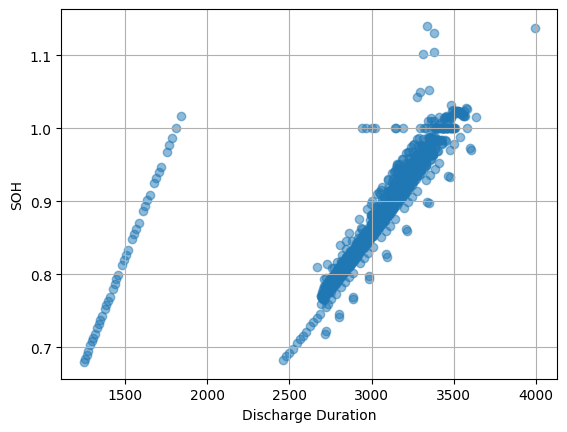

In [115]:
feature_df[["discharge_duration", "SOH"]].corr()

plt.scatter(
    feature_df["discharge_duration"],
    feature_df["SOH"],
    alpha=0.5
)

plt.xlabel("Discharge Duration")
plt.ylabel("SOH")
plt.grid(True)
plt.show()


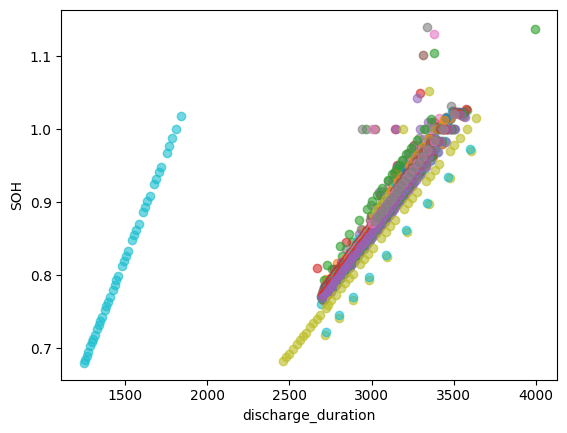

In [116]:
for cell_id, group in feature_df.groupby("cell_id"):
    plt.scatter(
        group["discharge_duration"],
        group["SOH"],
        label=cell_id,
        alpha=0.6
    )

plt.xlabel("discharge_duration")
plt.ylabel("SOH")
# plt.legend()
plt.show()

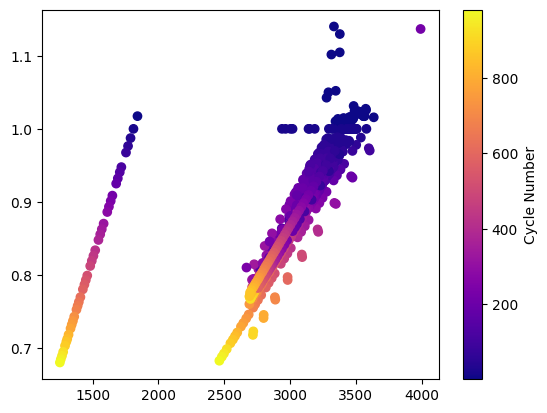

In [117]:
plt.scatter(
    feature_df["discharge_duration"],
    feature_df["SOH"],
    c=feature_df["cycle_number"],
    cmap="plasma"
)

plt.colorbar(label="Cycle Number")
plt.show()

In [118]:
feature_df["relative_discharge_duration"] = (
    feature_df["discharge_duration"]
    / feature_df.groupby("cell_id")["discharge_duration"].transform("first")
)

In [119]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd


def run_rf_experiment(
    df,
    feature_columns,
    target_column="SOH",
    test_size=0.2,
    random_state=42,
    n_estimators=200
):

    # -----------------------
    # 1. Data preparation
    # -----------------------
    data = df[feature_columns + [target_column]].dropna()

    features = data[feature_columns]
    target = data[target_column]

    features_train, features_test, target_train, target_test = train_test_split(
        features,
        target,
        test_size=test_size,
        random_state=random_state,
        shuffle=False  # wichtig bei time-like data
    )

    # -----------------------
    # 2. Model
    # -----------------------
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(features_train, target_train)

    # -----------------------
    # 3. Prediction + metrics
    # -----------------------
    pred = model.predict(features_test)

    mae = mean_absolute_error(target_test, pred)
    r2 = r2_score(target_test, pred)

    print("MAE:", round(mae, 4))
    print("R² :", round(r2, 4))

    # -----------------------
    # 4. Permutation importance
    # -----------------------
    result = permutation_importance(
        model,
        features_test,
        target_test,
        n_repeats=10,
        random_state=random_state,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": result.importances_mean,
        "std": result.importances_std
    }).sort_values("importance", ascending=False)

    print("\nFeature importance:")
    print(importance_df)

    # -----------------------
    # 5. Return everything
    # -----------------------
    return {
        "model": model,
        "mae": mae,
        "r2": r2,
        "importance": importance_df,
        "features_test": features_test,
        "target_test": target_test,
        "pred": pred
    }

In [120]:
voltage_features = [
    "DTW_V",
    "V_curvature",
    "V_std",
    "V_mean"
]

result_v = run_rf_experiment(feature_df, voltage_features)

MAE: 0.0187
R² : 0.8324

Feature importance:
       feature  importance       std
0        DTW_V    0.803325  0.103667
3       V_mean    0.334848  0.033107
1  V_curvature    0.217636  0.043036
2        V_std    0.217614  0.021607


In [121]:
best_features = [
    "DTW_V",
    "discharge_duration",
    "charge_duration"
]

result_best = run_rf_experiment(feature_df, best_features)

MAE: 0.0213
R² : 0.6698

Feature importance:
              feature  importance       std
1  discharge_duration    1.149002  0.093827
0               DTW_V    0.110294  0.018764
2     charge_duration    0.051078  0.004466


In [122]:
all_features = [
    "DTW_V",
    "DTW_I",
    "V_curvature",
    "V_std",
    "V_mean",
    "I_std",
    "charge_duration",
    "discharge_duration"
]

result_full = run_rf_experiment(feature_df, all_features)

MAE: 0.0205
R² : 0.6802

Feature importance:
              feature  importance       std
7  discharge_duration    1.158279  0.091944
5               I_std    0.031181  0.003930
1               DTW_I    0.024874  0.004435
0               DTW_V    0.021713  0.003530
6     charge_duration    0.011841  0.001595
4              V_mean    0.001200  0.004064
2         V_curvature    0.000091  0.000529
3               V_std   -0.000773  0.000959


In [123]:
results_table = pd.DataFrame([
    {"model": "voltage", "MAE": result_v["mae"], "R2": result_v["r2"]},
    {"model": "best", "MAE": result_best["mae"], "R2": result_best["r2"]},
    {"model": "full", "MAE": result_full["mae"], "R2": result_full["r2"]},
])

print(results_table)

     model       MAE        R2
0  voltage  0.018694  0.832365
1     best  0.021304  0.669775
2     full  0.020518  0.680182


In [124]:
# Grid search

feature_groups = {
    "voltage_core": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean"
    ],

    "time_only": [
        "charge_duration",
        "discharge_duration"
    ],

    "current_only": [
        "I_mean",
        "I_std",
        "DTW_I"
    ],

    "voltage+time": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean",
        "charge_duration",
        "discharge_duration"
    ],

    "full": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean",
        "DTW_I",
        "I_mean",
        "I_std",
        "charge_duration",
        "discharge_duration"
    ]
}


=== Running: voltage_core ===
MAE: 0.0187
R² : 0.8324

Feature importance:
       feature  importance       std
0        DTW_V    0.803325  0.103667
3       V_mean    0.334848  0.033107
1  V_curvature    0.217636  0.043036
2        V_std    0.217614  0.021607

=== Running: time_only ===
MAE: 0.0323
R² : 0.3077

Feature importance:
              feature  importance       std
1  discharge_duration    1.610794  0.126946
0     charge_duration    0.090054  0.013485

=== Running: current_only ===
MAE: 0.0167
R² : 0.907

Feature importance:
  feature  importance       std
2   DTW_I    0.909755  0.124551
1   I_std    0.611523  0.081448
0  I_mean    0.377208  0.030423

=== Running: voltage+time ===
MAE: 0.0214
R² : 0.6621

Feature importance:
              feature  importance       std
5  discharge_duration    1.162025  0.092798
0               DTW_V    0.063518  0.007835
4     charge_duration    0.050084  0.003930
2               V_std    0.002521  0.000917
1         V_curvature   -0.000486  

In [ ]:
# results_df = pd.DataFrame(results).sort_values("R2", ascending=False)

# print(results_df)

          model       MAE        R2  n_features
2  current_only  0.016655  0.906951           3
0  voltage_core  0.018694  0.832365           4
4          full  0.020565  0.673565           9
3  voltage+time  0.021441  0.662124           6
1     time_only  0.032349  0.307657           2


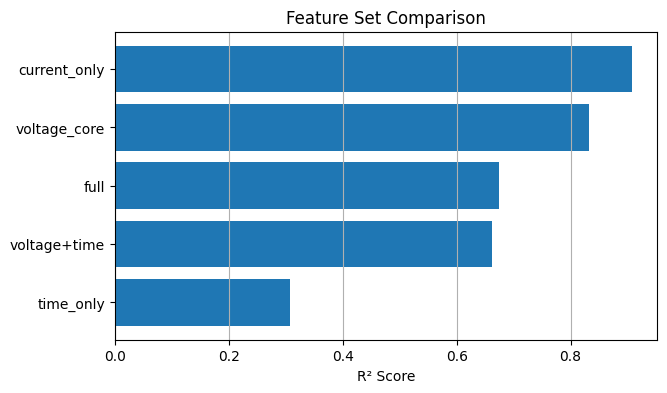

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(7,4))

# plt.barh(
#     results_df["model"],
#     results_df["R2"]
# )

# plt.xlabel("R² Score")
# plt.title("Feature Set Comparison")
# plt.grid(axis="x")

# plt.gca().invert_yaxis()
# plt.show()